In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print("Gpu enabled: ", torch.cuda.is_available())

Gpu enabled:  True


In [ ]:
# predicting final exam score

torch.manual_seed(42)

samples = 1000
weights = torch.randn(4,1, dtype=torch.float32)
bias = 44
hours_studied = torch.randint(1, 11, (samples, 1)).float()
attendance = torch.randint(60, 101, (samples, 1)).float()
assignments = torch.randint(1, 11, (samples, 1)).float()
sleep_hours = torch.randint(5, 10, (samples, 1)).float()

X = torch.cat(
    (hours_studied, attendance, assignments, sleep_hours),
    dim=1
)
X_min = X.min(dim=0).values
X_max = X.max(dim=0).values

X_normalized = (X - X_min) / (X_max - X_min)
y = torch.matmul(X_normalized,weights) + bias


X_normalized[:5], y[:5]

tensor([[1.],
        [4.],
        [9.],
        ...,
        [6.],
        [9.],
        [8.]])

In [181]:
split_percentage = int(0.8 * len(X))

x_train, y_train = X_normalized[:split_percentage], y[:split_percentage]
x_test, y_test = X_normalized[split_percentage:], y[split_percentage:]


len(x_train) , len(y_train), len(x_test),len(x_test)

(800, 800, 200, 200)

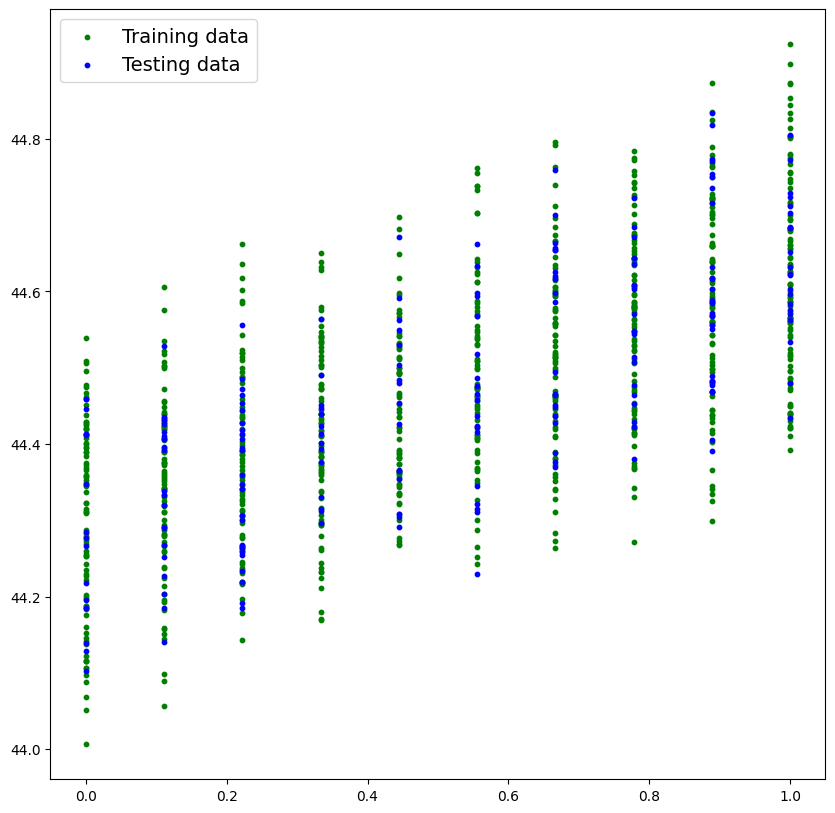

In [182]:
def graph(xtrain=x_train, ytrain=y_train, xtest=x_test,ytest=y_test,predictions=None):
    plt.figure(figsize=(10,10))
    
    plt.scatter(xtrain[:, 0], ytrain, color="green", s=10, label="Training data")
    plt.scatter(xtest[:, 0], ytest, color="blue", s=10, label="Testing data")
    
    if predictions is not None:
        plt.scatter(xtest[:, 0], predictions, color="red", s=10, label="Ypred")
    
    plt.legend(prop={"size": 14})    

graph()

In [183]:
class MarksPredictionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(4,1 , dtype=torch.float32, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float32, requires_grad=True))
        
    def forward(self,X:torch.Tensor):
        return torch.matmul(X, self.weights) + self.bias

tensor([[2.1444],
        [2.8754],
        [2.7353],
        [2.5503],
        [2.0609]])


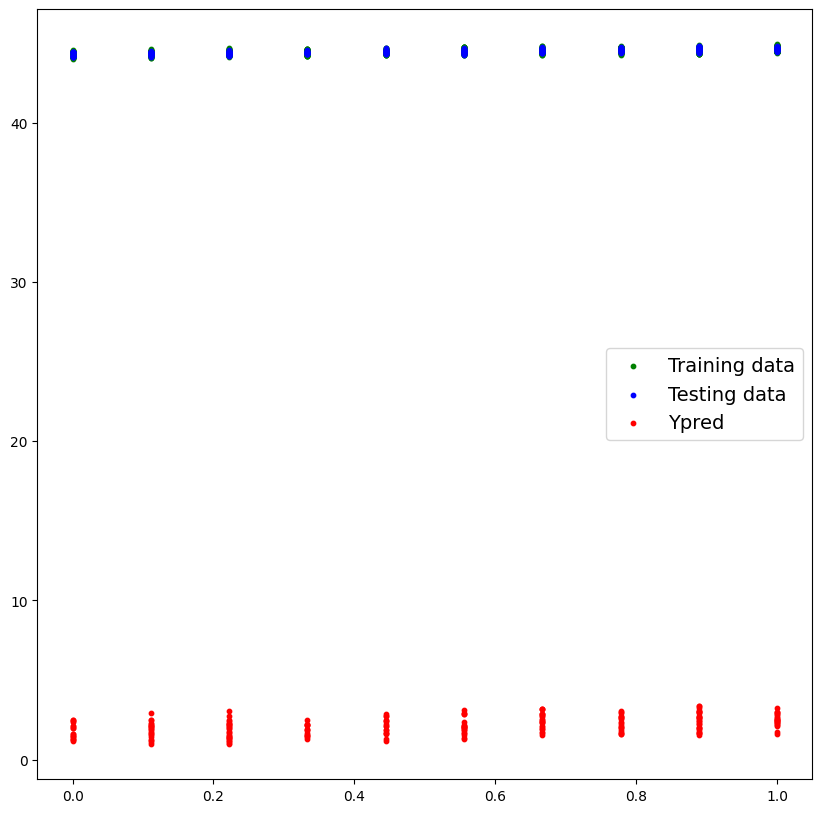

In [184]:
model = MarksPredictionModel()
with torch.inference_mode():    
    ypred = model(x_test)
print(ypred[:5])

graph(predictions=ypred)


In [185]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.5) 

optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.5
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [186]:
epochs = 2500

for epoch in range(epochs):
    model.train()
    
    yprediction = model(x_train)
    loss = loss_fn(yprediction, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    
    optimizer.step()
    
    model.eval()
    
    
    if epoch %  10 == 0:
        print(f"Epoch count: {epoch}, loss: {loss}")    
    

Epoch count: 0, loss: 42.320030212402344
Epoch count: 10, loss: 32.27997970581055
Epoch count: 20, loss: 22.23993492126465
Epoch count: 30, loss: 12.243168830871582
Epoch count: 40, loss: 6.427890777587891
Epoch count: 50, loss: 5.592498302459717
Epoch count: 60, loss: 5.345208168029785
Epoch count: 70, loss: 5.163539886474609
Epoch count: 80, loss: 4.986717700958252
Epoch count: 90, loss: 4.8108601570129395
Epoch count: 100, loss: 4.636059761047363
Epoch count: 110, loss: 4.463306903839111
Epoch count: 120, loss: 4.292109966278076
Epoch count: 130, loss: 4.121946334838867
Epoch count: 140, loss: 3.9529082775115967
Epoch count: 150, loss: 3.7842636108398438
Epoch count: 160, loss: 3.61674427986145
Epoch count: 170, loss: 3.449836492538452
Epoch count: 180, loss: 3.2835922241210938
Epoch count: 190, loss: 3.118142604827881
Epoch count: 200, loss: 2.953061103820801
Epoch count: 210, loss: 2.7881219387054443
Epoch count: 220, loss: 2.6237850189208984
Epoch count: 230, loss: 2.460124015808

tensor([[45.0355],
        [45.4320],
        [45.1509],
        [45.7303],
        [45.0551]])


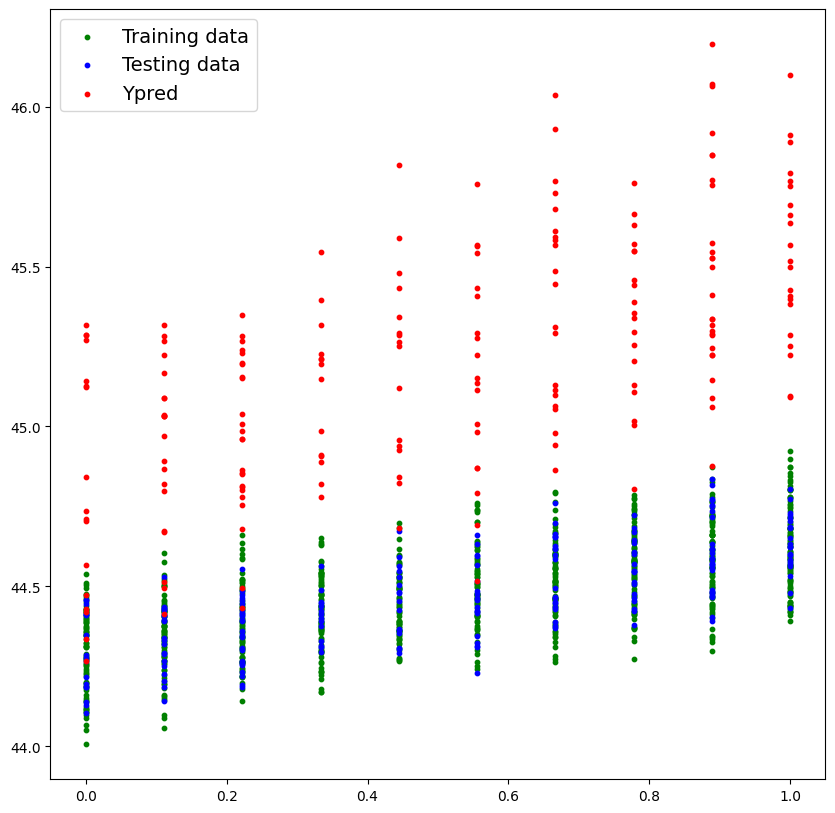

In [187]:
with torch.inference_mode():    
    ypred = model(x_test)
print(ypred[:5])

graph(predictions=ypred)


In [188]:
import pandas as pd

# Visualize dataset features & target score
df = pd.DataFrame(
    X.detach().cpu().numpy(),
    columns=["Hours Studied", "Attendance (%)", "Assignments", "Sleep Hours"]
)
df["Final Exam Score"] = y.detach().cpu().numpy()

display(df.head(10))

# Compare Actual vs Predicted test set scores
results_df = pd.DataFrame({
    "Hours Studied": x_test[:, 0].detach().cpu().numpy(),
    "Attendance (%)": x_test[:, 1].detach().cpu().numpy(),
    "Assignments": x_test[:, 2].detach().cpu().numpy(),
    "Sleep Hours": x_test[:, 3].detach().cpu().numpy(),
    "Actual Score": y_test.squeeze().detach().cpu().numpy(),
    "Predicted Score": ypred.squeeze().detach().cpu().numpy(),
    "Abs Difference": torch.abs(y_test - ypred).squeeze().detach().cpu().numpy()
})

display(results_df.round(2).head(10))


,Hours Studied,Attendance (%),Assignments,Sleep Hours,Final Exam Score
0,1.0,92.0,9.0,5.0,44.311459
1,4.0,74.0,9.0,5.0,44.365723
2,9.0,94.0,5.0,5.0,44.512974
3,5.0,73.0,1.0,8.0,44.364254
4,1.0,87.0,6.0,8.0,44.389954
5,5.0,61.0,4.0,9.0,44.461346
6,2.0,81.0,6.0,8.0,44.408043
7,3.0,60.0,8.0,9.0,44.487514
8,6.0,95.0,9.0,9.0,44.738503
9,6.0,73.0,4.0,9.0,44.537399


,Hours Studied,Attendance (%),Assignments,Sleep Hours,Actual Score,Predicted Score,Abs Difference
0,0.11,0.30,0.44,1.00,44.410000,45.040001,0.62
1,0.44,0.22,0.78,1.00,44.590000,45.430000,0.84
2,0.22,0.12,0.89,0.75,44.470001,45.150002,0.68
3,0.67,0.98,0.89,0.25,44.619999,45.730000,1.11
4,0.67,0.32,0.44,0.25,44.430000,45.060001,0.63
5,0.33,0.15,0.56,0.50,44.380001,44.910000,0.53
6,1.00,0.40,0.56,0.25,44.580002,45.410000,0.83
7,0.00,0.65,0.33,0.50,44.279999,44.840000,0.57
8,0.00,0.15,0.11,0.25,44.099998,44.270000,0.16
9,0.44,0.40,0.67,0.75,44.529999,45.340000,0.81


In [189]:
print(model.state_dict())
print("--------------------------")
print(weights)
print(bias)

OrderedDict({'weights': tensor([[0.7107],
        [0.6165],
        [0.6175],
        [0.5209]]), 'bias': tensor([43.9763])})
--------------------------
tensor([[0.3367],
        [0.1288],
        [0.2345],
        [0.2303]])
44
